In [ ]:
import pandas as pd

df = pd.read_csv("email_spam.csv", encoding="latin-1")

# Keep only required columns
df = df[['v1','v2']]

# Rename columns for clarity
df.columns = ['label','message']

df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
df.shape


(5572, 2)

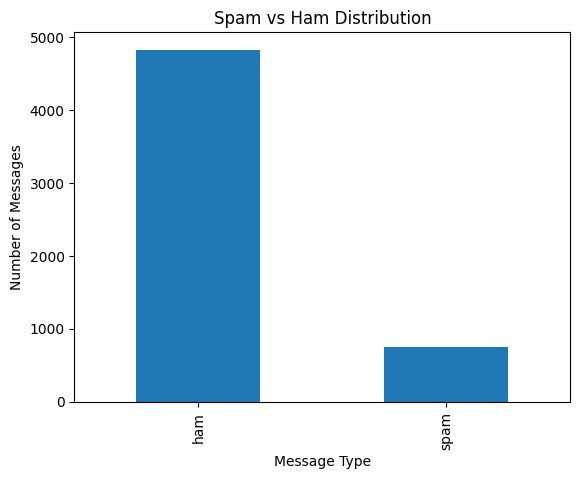

In [ ]:
df['label'].value_counts()
import matplotlib.pyplot as plt

df['label'].value_counts().plot(kind='bar')

plt.title("Spam vs Ham Distribution")
plt.xlabel("Message Type")
plt.ylabel("Number of Messages")

plt.show()


In [ ]:
df.isnull().sum()

,0
label,0
message,0


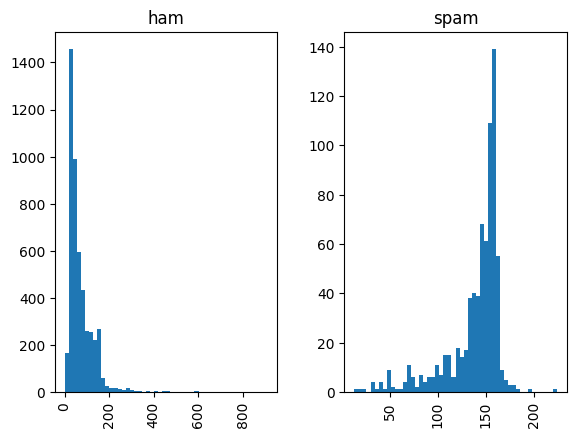

In [ ]:
df['length'] = df['message'].apply(len)

df.groupby('label')['length'].mean()

df.hist(column='length', by='label', bins=50)
plt.show()

In [ ]:
import numpy as np
import re
import nltk
import string

In [ ]:
nltk.download('stopwords')
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
df['label'] = df['label'].map({'ham':0, 'spam':1})

In [ ]:
df.head()

,label,message,length
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [ ]:
df['message'] = df['message'].str.lower()

In [ ]:
def remove_punctuation(text):
    return text.translate(str.maketrans('', '', string.punctuation))

df['message'] = df['message'].apply(remove_punctuation)

In [ ]:
df['message'] = df['message'].apply(lambda x: re.sub(r'\d+', '', x))

In [ ]:
df['tokens'] = df['message'].apply(lambda x: x.split())

In [ ]:
stop_words = set(stopwords.words('english'))

df['tokens'] = df['tokens'].apply(
    lambda words: [word for word in words if word not in stop_words]
)

In [ ]:
stemmer = PorterStemmer()

df['tokens'] = df['tokens'].apply(
    lambda words: [stemmer.stem(word) for word in words]
)

In [ ]:
df['clean_message'] = df['tokens'].apply(lambda words: " ".join(words))

In [ ]:
df[['message','clean_message']].head()

,message,clean_message
0,go until jurong point crazy available only in ...,go jurong point crazi avail bugi n great world...
1,ok lar joking wif u oni,ok lar joke wif u oni
2,free entry in a wkly comp to win fa cup final...,free entri wkli comp win fa cup final tkt st m...
3,u dun say so early hor u c already then say,u dun say earli hor u c alreadi say
4,nah i dont think he goes to usf he lives aroun...,nah dont think goe usf live around though


In [ ]:
X_clean = df['clean_message']
y = df['label']

In [ ]:
!pip install transformers

In [ ]:
import torch
from transformers import DistilBertModel, DistilBertTokenizer
import numpy as np

# Load pre-trained model and tokenizer
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')
model = DistilBertModel.from_pretrained('distilbert-base-uncased')

def extract_distilbert_features(text_list):
    model.eval()
    features = []

    for text in text_list:
        inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=128)
        with torch.no_grad():
            outputs = model(**inputs)

        # Get the [CLS] token embedding (index 0)
        cls_embedding = outputs.last_hidden_state[:, 0, :].numpy()
        features.append(cls_embedding.flatten())

    return np.array(features)

# Applying extraction to the cleaned dataset
X_features = extract_distilbert_features(df['clean_message'].tolist())

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier

models = {

    "Hybrid_SVM": SVC(kernel='linear', probability=True),

    "Hybrid_RandomForest":
    RandomForestClassifier(n_estimators=100),

    "Hybrid_GradientBoost":
    GradientBoostingClassifier(),

    "Hybrid_LogisticRegression":
    LogisticRegression(max_iter=1000),

    "Hybrid_KNN":
    KNeighborsClassifier(n_neighbors=5),

    "Hybrid_DecisionTree":
    DecisionTreeClassifier(),

    "Hybrid_ExtraTrees":
    ExtraTreesClassifier(n_estimators=100),

    "Hybrid_AdaBoost":
    AdaBoostClassifier(),

    "Hybrid_GaussianNB":
    GaussianNB(),

    "Hybrid_MLP":
    MLPClassifier(hidden_layer_sizes=(100,), max_iter=500)
}

In [ ]:
from sklearn.model_selection import train_test_split

# Split data (80% Training, 20% Testing)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_features,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)
# Training Loop
for name, model_obj in models.items():
    print(f"Training {name}...")
    model_obj.fit(X_train, y_train)

Training Hybrid_SVM...
Training Hybrid_RandomForest...
Training Hybrid_GradientBoost...
Training Hybrid_LogisticRegression...
Training Hybrid_KNN...
Training Hybrid_DecisionTree...
Training Hybrid_ExtraTrees...
Training Hybrid_AdaBoost...
Training Hybrid_GaussianNB...
Training Hybrid_MLP...


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

evaluation_results = {}

for name, model_obj in models.items():

    predictions = model_obj.predict(X_test)

    accuracy = accuracy_score(y_test, predictions)

    report = classification_report(
        y_test,
        predictions,
        output_dict=True
    )

    evaluation_results[name] = {
        "Accuracy": accuracy,
        "Precision": report['1']['precision'],   # spam class
        "Recall": report['1']['recall'],
        "F1-score": report['1']['f1-score']
    }

    print(f"\n--- {name} Results ---")

    print("Confusion Matrix:\n",
          confusion_matrix(y_test, predictions))

    print("Accuracy:", accuracy)
    print("Precision:", report['1']['precision'])
    print("Recall:", report['1']['recall'])
    print("F1-score:", report['1']['f1-score'])

# Convert results to table
results_df = pd.DataFrame(evaluation_results).T

results_df


--- Hybrid_SVM Results ---
Confusion Matrix:
 [[959   7]
 [ 17 132]]
Accuracy: 0.97847533632287
Precision: 0.9496402877697842
Recall: 0.8859060402684564
F1-score: 0.9166666666666666

--- Hybrid_RandomForest Results ---
Confusion Matrix:
 [[956  10]
 [ 35 114]]
Accuracy: 0.9596412556053812
Precision: 0.9193548387096774
Recall: 0.7651006711409396
F1-score: 0.8351648351648352

--- Hybrid_GradientBoost Results ---
Confusion Matrix:
 [[954  12]
 [ 26 123]]
Accuracy: 0.9659192825112107
Precision: 0.9111111111111111
Recall: 0.825503355704698
F1-score: 0.8661971830985915

--- Hybrid_LogisticRegression Results ---
Confusion Matrix:
 [[960   6]
 [ 16 133]]
Accuracy: 0.9802690582959641
Precision: 0.9568345323741008
Recall: 0.8926174496644296
F1-score: 0.9236111111111112

--- Hybrid_KNN Results ---
Confusion Matrix:
 [[943  23]
 [ 21 128]]
Accuracy: 0.9605381165919282
Precision: 0.847682119205298
Recall: 0.8590604026845637
F1-score: 0.8533333333333334

--- Hybrid_DecisionTree Results ---
Confusio

,Accuracy,Precision,Recall,F1-score
Hybrid_SVM,0.978475,0.949640,0.885906,0.916667
Hybrid_RandomForest,0.959641,0.919355,0.765101,0.835165
Hybrid_GradientBoost,0.965919,0.911111,0.825503,0.866197
Hybrid_LogisticRegression,0.980269,0.956835,0.892617,0.923611
Hybrid_KNN,0.960538,0.847682,0.859060,0.853333
Hybrid_DecisionTree,0.940807,0.761006,0.812081,0.785714
Hybrid_ExtraTrees,0.962332,0.957265,0.751678,0.842105
Hybrid_AdaBoost,0.955157,0.832215,0.832215,0.832215
Hybrid_GaussianNB,0.929148,0.673267,0.912752,0.774929
Hybrid_MLP,0.981166,0.950704,0.906040,0.927835


In [ ]:
import joblib
from transformers import DistilBertTokenizer, DistilBertModel

# Select best model using F1-score
best_model_name = max(
    evaluation_results,
    key=lambda x: evaluation_results[x]['F1-score']
)

best_model = models[best_model_name]

# Save trained classifier
joblib.dump(best_model, "best_spam_model.pkl")

# Save tokenizer (needed during prediction)
tokenizer.save_pretrained("distilbert_tokenizer")

print(f"Selected Model: {best_model_name}")
print("Best model and tokenizer saved successfully.")

Selected Model: Hybrid_MLP
Best model and tokenizer saved successfully.


In [ ]:
!pip install flask transformers torch pyngrok

In [ ]:
# ==========================================================
# 1. INSTALL REQUIRED LIBRARIES
# ==========================================================
!pip install flask transformers torch joblib

# ==========================================================
# 2. IMPORT LIBRARIES
# ==========================================================
import os
import joblib
import torch
from flask import Flask, request, render_template
from transformers import DistilBertTokenizer, DistilBertModel
from google.colab.output import eval_js

# ==========================================================
# 3. CREATE FRONTEND TEMPLATE
# ==========================================================
if not os.path.exists("templates"):
    os.makedirs("templates")

html_content = """
<!DOCTYPE html>
<html>
<head>
<title>Spam Detection System</title>

<style>

body{
font-family:Arial;
background:#eef2f7;
display:flex;
justify-content:center;
align-items:center;
height:100vh;
}

.card{
background:white;
padding:40px;
border-radius:15px;
box-shadow:0 10px 25px rgba(0,0,0,0.1);
width:500px;
text-align:center;
}

textarea{
width:100%;
height:120px;
padding:15px;
border-radius:8px;
border:1px solid #ddd;
}

button{
margin-top:20px;
padding:12px 30px;
border:none;
background:#4A90E2;
color:white;
border-radius:25px;
cursor:pointer;
}

.result{
margin-top:20px;
font-size:18px;
font-weight:bold;
}

</style>

</head>

<body>

<div class="card">

<h2>Spam Detection System</h2>

<p>Hybrid DistilBERT + Machine Learning Classifier</p>

<form action="/predict" method="post">

<textarea name="message"
placeholder="Enter SMS or Email text here..."
required></textarea>

<br>

<button type="submit">Check Message</button>

</form>

<div class="result">

{{ prediction_text }}

</div>

</div>

</body>
</html>
"""

with open("templates/index.html", "w") as f:
    f.write(html_content)

# ==========================================================
# 4. LOAD TRAINED MODELS
# ==========================================================
print("Loading classifier and DistilBERT...")

model_ml = joblib.load("best_spam_model.pkl")

tokenizer = DistilBertTokenizer.from_pretrained(
    "distilbert-base-uncased"
)

bert_model = DistilBertModel.from_pretrained(
    "distilbert-base-uncased"
)

bert_model.eval()

print("Models loaded successfully!")

# ==========================================================
# 5. CREATE FLASK APP
# ==========================================================
app = Flask(__name__)

@app.route("/")
def home():
    return render_template("index.html")


@app.route("/predict", methods=["POST"])
def predict():

    message = request.form["message"]

    # DistilBERT embedding extraction
    inputs = tokenizer(
        message,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    with torch.no_grad():
        outputs = bert_model(**inputs)

    embedding = outputs.last_hidden_state[:,0,:].cpu().numpy()

    # ML classifier prediction
    prediction = model_ml.predict(embedding)

    result = "SPAM" if prediction[0]==1 else "LEGITIMATE (HAM)"

    return render_template(
        "index.html",
        prediction_text=f"This message is: {result}"
    )

# ==========================================================
# 6. RUN WEB APPLICATION INSIDE COLAB
# ==========================================================
print("Click the link below to open the web app:")

print(eval_js("google.colab.kernel.proxyPort(5000)"))

app.run(port=5000)

Loading classifier and DistilBERT...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Models loaded successfully!
Click the link below to open the web app:
https://5000-m-s-kkb-usc1a1-oz7mm9too24t-a.us-central1-1.prod.colab.dev
 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5000
INFO:werkzeug:Press CTRL+C to quit
INFO:werkzeug:127.0.0.1 - - [17/Apr/2026 10:37:44] "GET / HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [17/Apr/2026 10:37:48] "GET /favicon.ico HTTP/1.1" 404 -
INFO:werkzeug:127.0.0.1 - - [17/Apr/2026 10:40:37] "POST /predict HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [17/Apr/2026 10:41:50] "POST /predict HTTP/1.1" 200 -
